In [1]:
# Section 0: Setup - Import libraries

import numpy as np              # For numerical operations and arrays
import pandas as pd             # For working with tabular data
import matplotlib.pyplot as plt # For plotting graphs

from sklearn.datasets import fetch_california_housing   # Real world regression dataset
from sklearn.model_selection import train_test_split    # Train test split utility
from sklearn.linear_model import LinearRegression       # Multiple Linear Regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Evaluation metrics
from sklearn.preprocessing import PolynomialFeatures    # For generating polynomial features
from sklearn.pipeline import Pipeline                   # For chaining preprocessing and model

# Configure matplotlib for slightly nicer default plots
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

In [2]:
california = fetch_california_housing(as_frame=True)
df = california.frame.copy()

In [3]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.shape

(20640, 9)

In [7]:
col = df.columns.to_list()

In [8]:
col

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude',
 'MedHouseVal']

In [14]:
target_col = col[-1]
feature_cols = col[:6]

X = df[feature_cols]
y = df[target_col]

In [15]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467


In [16]:
y.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

In [17]:
X.shape

(20640, 6)

In [18]:
y.shape

(20640,)

               MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
MedInc       1.000000 -0.119034  0.326895  -0.062040    0.004834  0.018766   
HouseAge    -0.119034  1.000000 -0.153277  -0.077747   -0.296244  0.013191   
AveRooms     0.326895 -0.153277  1.000000   0.847621   -0.072213 -0.004852   
AveBedrms   -0.062040 -0.077747  0.847621   1.000000   -0.066197 -0.006181   
Population   0.004834 -0.296244 -0.072213  -0.066197    1.000000  0.069863   
AveOccup     0.018766  0.013191 -0.004852  -0.006181    0.069863  1.000000   
MedHouseVal  0.688075  0.105623  0.151948  -0.046701   -0.024650 -0.023737   

             MedHouseVal  
MedInc          0.688075  
HouseAge        0.105623  
AveRooms        0.151948  
AveBedrms      -0.046701  
Population     -0.024650  
AveOccup       -0.023737  
MedHouseVal     1.000000  


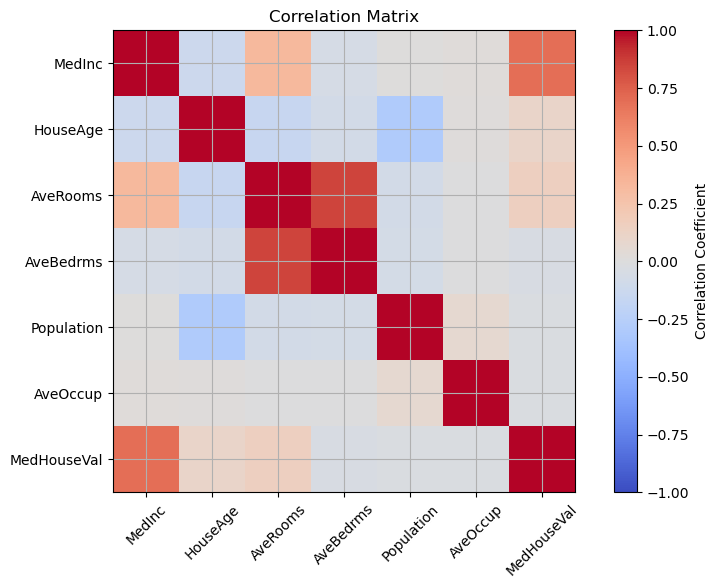

In [20]:
corr_matrix = df[feature_cols + [target_col]].corr()
print(corr_matrix)
plt.figure(figsize=(10, 6))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix)), corr_matrix.index)
plt.title('Correlation Matrix')
plt.show()

In [21]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((16512, 6), (4128, 6), (16512,), (4128,))

In [23]:
lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)

LinearRegression()

In [25]:
lin_reg.intercept_

np.float64(-0.5528727644615232)

In [26]:
for feature_name, coef in zip(feature_cols, lin_reg.coef_):
    print(f"{feature_name}: {coef}")

MedInc: 0.5461607791074247
HouseAge: 0.01678790906256819
AveRooms: -0.22391994400480014
AveBedrms: 1.1154926114808361
Population: 2.316719736821654e-05
AveOccup: -0.004618231345407257


In [30]:
y_train_pred = lin_reg.predict(x_train)
y_test_pred = lin_reg.predict(x_test)

print("First 5 Predictions on Training Set:", y_train_pred[:5])
print("First 5 Actuals on Training Set:", y_train.iloc[:5].values)
print("First 5 Predictions on Test Set:", y_test_pred[:5])
print("First 5 Actuals on Test Set:", y_test.iloc[:5].values)

First 5 Predictions on Training Set: [1.81673013 2.53390529 1.62758681 1.38370232 1.98137714]
First 5 Actuals on Training Set: [1.03  3.821 1.726 0.934 0.965]
First 5 Predictions on Test Set: [1.00100537 1.56005635 2.67713262 2.64763331 1.98229968]
First 5 Actuals on Test Set: [0.477   0.458   5.00001 2.186   2.78   ]


In [32]:
def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2


train_mae, train_mse, train_rmse, train_r2 = evaluate_regression(y_train, y_train_pred)
test_mae, test_mse, test_rmse, test_r2 = evaluate_regression(y_test, y_test_pred)
print("Training Set Evaluation:")
print(f"MAE: {train_mae:.4f}, MSE: {train_mse:.4f}, RMSE: {train_rmse:.4f}, R²: {train_r2:.4f}")
print("Test Set Evaluation:")
print(f"MAE: {test_mae:.4f}, MSE: {test_mse:.4f}, RMSE: {test_rmse:.4f}, R²: {test_r2:.4f}")

Training Set Evaluation:
MAE: 0.5709, MSE: 0.6070, RMSE: 0.7791, R²: 0.5459
Test Set Evaluation:
MAE: 0.5792, MSE: 0.6422, RMSE: 0.8014, R²: 0.5099


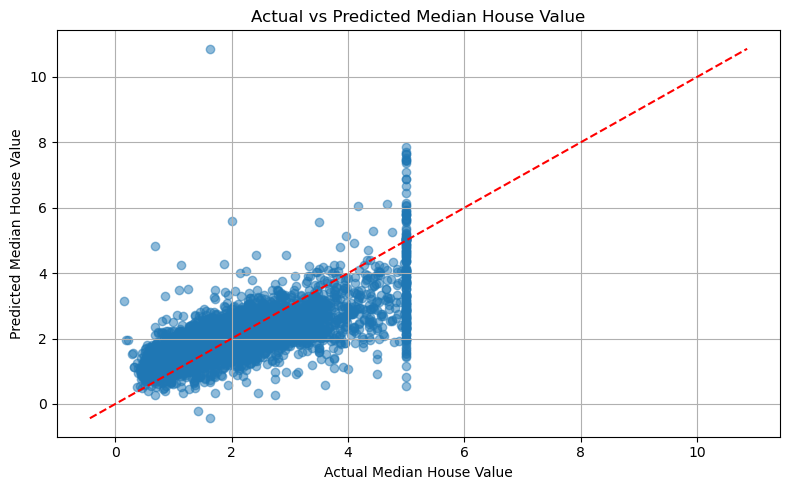

In [33]:
plt.figure()
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs Predicted Median House Value")

min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
plt.tight_layout()
plt.show()

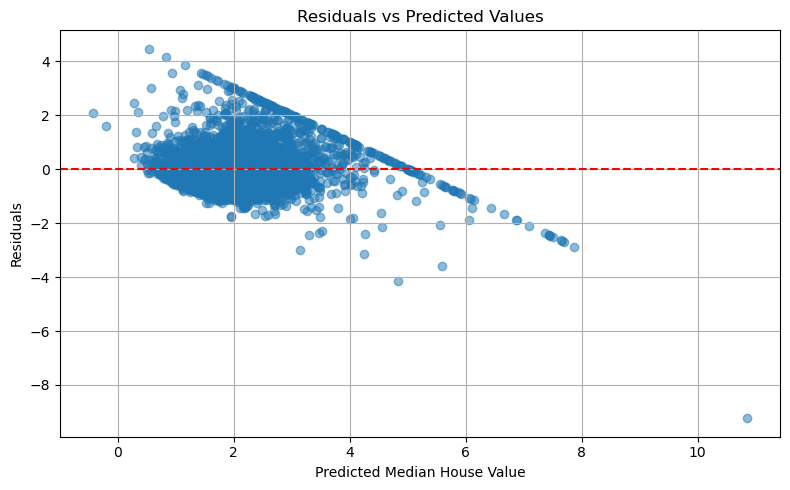

In [34]:
residuals = y_test - y_test_pred
plt.figure()
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Median House Value")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.tight_layout()
plt.show()